In [1]:
import mp_api
import pandas as pd
from mp_offline.client import MPOffline, MaterialSummary
from pymatgen.core.composition import Composition
from pymatgen.core import Structure
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from collections import Counter

from copy import deepcopy

Steps

1. Prepare the data
2. Select materials that are binary/ternary
3. Form groups based on composition
4. Form groups based on local geometry
5. Filter by volume changes and band gaps
6. Form the final candidates for calculation

## Loading data using `mp_offline`

In [2]:
client = MPOffline()

col =['material_id', 'energy_above_hull', 'composition', 'structure', 'json_data']
entries = client.query_all(MaterialSummary.energy_above_hull < 0.01, project=col)
df = pd.DataFrame(entries, columns=col)
df['composition'] = df['composition'].apply(Composition)
df['structure'] = df['structure'].apply(Structure.from_dict)
df['band_gap'] = df['json_data'].apply(lambda x: x['band_gap'])

df['nelems'] = df['composition'].apply(lambda x: len(x.keys()))

df['reduced_composition'] = df.composition.apply(lambda x: x.get_reduced_composition_and_factor()[0])

df.set_index('material_id', inplace=True)

df_t = df.loc[(df['nelems'] == 3)
            & (df['band_gap'] < 1), :]

0it [00:00, ?it/s]

/home/bonan/miniconda3/envs/work/lib/python3.12/site-packages/pymatgen/core/periodic_table.py:289: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(
/home/bonan/miniconda3/envs/work/lib/python3.12/site-packages/pymatgen/core/periodic_table.py:289: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(
/home/bonan/miniconda3/envs/work/lib/python3.12/site-packages/pymatgen/core/periodic_table.py:289: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(


## Match materials based on compositions

Group material with reduced formula that shares common elements

AxByCz -> HxKyLz

For each existing reduced composition, we have three permutations for the first(to be varied composition).

For each reduced composition, record the ByCz combination

In [3]:

all_fixed_parts = {}
for index, row in df_t.iterrows():
    rd = row.reduced_composition
    elems = list(rd.keys())
    for i in [[0, 1, 2], [0, 2, 1], [1,2, 0]]:
        # Record the fixed 
        fixed_comp = Composition({elems[k]: rd[elems[k]]for k in i[:2]}).reduced_formula + f'X{int(rd[elems[i[2]]])}'
        # Record the material ID and the corresponding A element (that may change)
        if fixed_comp in all_fixed_parts:
            all_fixed_parts[fixed_comp].append([index, str(elems[i[2]]), row.band_gap])
        else:
            all_fixed_parts[fixed_comp] = [[index, str(elems[i[2]]), row.band_gap]]
all_fixed_parts = {k: v for k, v in all_fixed_parts.items() if len(v) > 1}
print(len(all_fixed_parts))



8362


In [4]:
all_fixed_parts

{'Zr4Sb7X1': [['mp-1195070', 'Cu', 0.0], ['mp-1215353', 'Ge', 0.0]],
 'CuS4X2': [['mp-28888', 'Pt', 0.14010000000000034],
  ['mp-15613', 'Rh', 0.0],
  ['mp-3925', 'Co', 0.0],
  ['mp-14025', 'Zr', 0.0],
  ['mp-15065', 'Ir', 0.0],
  ['mp-3951', 'Ti', 0.0],
  ['mp-22803', 'Cr', 0.0],
  ['mp-1220691', 'Nb', 0.0]],
 'CoNiX4': [['mp-1226048', 'Te', 0.0],
  ['mp-1226006', 'Si', 0.0],
  ['mp-1217247', 'Ti', 0.0],
  ['mp-1217989', 'Ta', 0.0],
  ['mp-1226054', 'Te', 0.0],
  ['mp-1215379', 'Zr', 0.0]],
 'CoTe4X1': [['mp-1226048', 'Ni', 0.0], ['mp-1226054', 'Ni', 0.0]],
 'NiTe4X1': [['mp-1226048', 'Co', 0.0], ['mp-1226054', 'Co', 0.0]],
 'Te4AuX1': [['mp-12743', 'Cr', 0.0], ['mp-3291', 'Ag', 0.0]],
 'Y5Si3X1': [['mp-1216261', 'C', 0.0], ['mp-1189066', 'H', 0.0]],
 'Si12CX20': [['mp-1216261', 'Y', 0.0], ['mp-1225168', 'Er', 0.0]],
 'LiS4X2': [['mp-1222722', 'Zr', 0.0],
  ['mp-1238817', 'Cr', 0.0],
  ['mp-1223278', 'Ti', 0.0],
  ['mp-1045401', 'Mn', 0.0],
  ['mp-1045358', 'Cr', 0.0],
  ['mp-1045435'

Checking the distribution of the group sizes

(array([6.021e+03, 9.940e+02, 4.590e+02, 4.270e+02, 1.790e+02, 7.600e+01,
        7.700e+01, 4.000e+01, 2.500e+01, 1.700e+01, 1.700e+01, 6.000e+00,
        2.000e+00, 4.000e+00, 2.000e+00, 3.000e+00, 7.000e+00, 2.000e+00,
        3.000e+00, 1.000e+00]),
 array([ 2. ,  4.3,  6.6,  8.9, 11.2, 13.5, 15.8, 18.1, 20.4, 22.7, 25. ,
        27.3, 29.6, 31.9, 34.2, 36.5, 38.8, 41.1, 43.4, 45.7, 48. ]),
 <BarContainer object of 20 artists>)

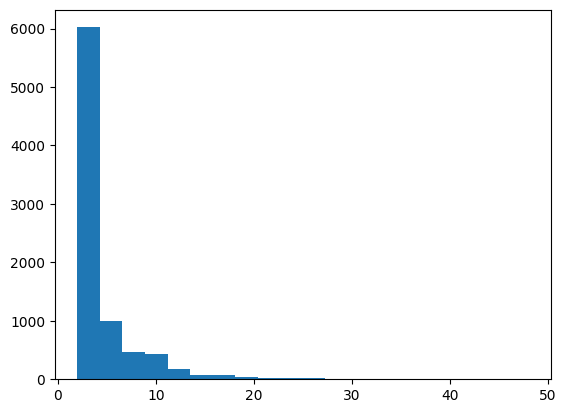

In [5]:
sizes = {k: len(v) for k, v in all_fixed_parts.items()}
plt.hist(list(sizes.values()), bins=20)

In [6]:
counter = Counter(sizes.values())
counter

Counter({2: 3626,
         3: 1513,
         4: 882,
         5: 592,
         6: 402,
         7: 259,
         8: 200,
         9: 177,
         10: 157,
         12: 94,
         11: 93,
         13: 85,
         14: 54,
         17: 29,
         18: 25,
         16: 23,
         15: 22,
         19: 21,
         20: 19,
         21: 18,
         23: 10,
         26: 7,
         24: 7,
         25: 7,
         22: 7,
         40: 5,
         29: 3,
         44: 3,
         27: 3,
         28: 3,
         33: 2,
         38: 2,
         36: 2,
         31: 2,
         48: 1,
         43: 1,
         32: 1,
         39: 1,
         41: 1,
         34: 1,
         37: 1,
         42: 1})

## Further Match materials based on local environments

The next step

Compare the local environments between the matches based on the composition

The code below uses the robocrystallographer to generate description of the structure. In practice we use a python script and parallel to generate the descriptions of a set of materials

Match strategy:

For each group that we match based on the composition, find the matched structures inside the group

- 

In [7]:
from monty.serialization import loadfn
import numpy as np

In [8]:
from pymatgen.core import Element, Species, Composition

In [9]:
Species('Cu3.2+').symbol

'Cu'

In [10]:
condensed_data = loadfn('condensed_combined.json')

In [28]:
def find_unique_envs(condensed_structures):
    """Locate the unique environments of different centre atoms in each structure"""
    envs = []
    for cs in condensed_structures:
        if cs is None:
            envs.append([None, None])
            continue
        comp = Composition(cs['formula'])
        env = {str(key): set() for key in comp}
        for site_id, site in cs['sites'].items():
            pform = site['poly_formula']
            ptype = site['geometry']['type']
            env[Species(site['element']).symbol].add((str(pform), ptype))
        envs.append([cs['formula'], env])
    return envs

def swap_elem_by_X(name, elem):
    """Swap the element in a string by X. For example CoCa3 to CoX3"""
    temp_comp = {key.symbol: value for key, value in Composition(name).items()}
    
    if elem in temp_comp:
        temp_comp['X'] = temp_comp[elem]
        temp_comp.pop(elem)
        name = Composition(temp_comp).formula
    return name    

def group_likestructures(envs, comp_template, mp_ids):
    """locate structures with simular environment and group them together"""
    # Result holder
    reprs = []
    aelems = []
    comps = []
    xelems = []
    # Find the spectator elements - those not changed 
    spectator_elements = [x.symbol for x in  Composition(comp_template).keys() if x.symbol != 'X']
    
    #print(spectator_elements)
    # Iterate through all environments
    for comp, item in envs:
        # Skip if the information is missinrg, we make a random representation to avoid any matching
        if item is None:
            reprs.append(str(np.random.rand()))
            aelems.append('MISSING')
            comps.append('MISSING')
            xelems.append('MISSING')
            continue
        
        # Find the X element which is not the spectator_elements
        x_candidiate = list(filter(lambda x: x not in spectator_elements, item))
        assert len(x_candidiate) == 1
        elem = x_candidiate[0]

        # For an descriptor the environment we replace elem to X
       
        repr = str(sorted(list(item[elem]))) + '|'
        rest = []
        for x in spectator_elements:
            rest.append(x)
            for entry in item[x]:
                name, type = entry
                # Swap the X element back to X should it appear in the name part of the environment
                if name != 'None':
                    name = swap_elem_by_X(name, elem)
                rest.append(name + ',' + type)
        repr = repr + '|'.join(rest)
        
        # Collect results
        reprs.append(repr)
        aelems.append(sorted(spectator_elements))
        xelems.append(elem)
        comps.append(comp)
    #print(reprs)
    # Convert to numpy array
    aelems = np.array(aelems)
    comps = np.array(comps)
    xelems = np.array(xelems)
    # Find unique environment
    _, unique_idx, labels =  np.unique(reprs, return_index=True, return_inverse=True)

    # Filter for valid groups, e.g. there are more than one structures in the group    
    valid_group = [] 
    for idx in unique_idx:
        group_id = labels[idx]
        mask = labels == group_id
        # Number of structures in the group
        nin_group = sum(mask)
        # Elements in the group
        if nin_group > 1:
            valid_group.append({'entry_idx': np.where(mask)[0],   # Index of the entry in the original list of case 
                                #'unique_group_elements': group_elements.tolist(),
                                'A_elements': aelems[mask].tolist(),
                                'Compositions': comps[mask].tolist(),
                                'group_size': nin_group, 
                                'X_element': xelems[mask].tolist(),
                                'mp_ids': mp_ids[mask].tolist(),
                                'group_repr': reprs[idx]})
    return valid_group

In [12]:
%pdb

Automatic pdb calling has been turned ON


In [29]:
all_groups = []
for key in tqdm(all_fixed_parts):
    mp_ids = np.array([x[0] for x in all_fixed_parts[key]])
    valid_ids = np.array([x for x in mp_ids if x + '.json' in condensed_data])
    envs = find_unique_envs([condensed_data[x + '.json'] for x in valid_ids])
    groups = group_likestructures(envs, key, valid_ids)
    for entry in groups:
        entry['band_gaps'] = [all_fixed_parts[key][i][2] for i in entry['entry_idx']]
    all_groups.extend(groups) 

all_groups = [group for group in all_groups if len(np.unique(group['X_element'])) > 1]

  0%|          | 0/8362 [00:00<?, ?it/s]

Further reduce the valid number of groups

In [30]:
unwanted_elements = []
elems = ['U', 'Th', 'Po', 'Tl', 'Hg']
for group in all_groups:
    group = deepcopy(group)
    # Must not contian radiative 
    if any(x in group['A_elements'][0] for x in elems):
        continue
    # Select entry where the X_element is not the unwanted list of elements
    valid_idx = [idx for idx, value in enumerate(group['X_element']) if all(x != value for x in elems)]
    for key in group.keys():
        if key == 'group_size':
            continue
        group[key] = [group[key][i] for i in valid_idx]
    if len(group['mp_ids']) > 1:
        unwanted_elements.append(group)

In [31]:
valid_groups = []
print(f'Number of total groups: {len(all_groups)}')
for group in unwanted_elements:
    gaps = group['band_gaps']
    
    if any(x >0 for x in  gaps) and any(x == 0 for x in gaps):
        valid_groups.append(group)
print(f'Number of filtered groups: {len(valid_groups)}')

Number of total groups: 5745
Number of filtered groups: 502


In [32]:
group_df = pd.DataFrame.from_records(valid_groups).sort_values('group_size', ascending=False)
group_df 

,entry_idx,A_elements,Compositions,group_size,X_element,mp_ids,group_repr,band_gaps
406,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[Rh, Zn], [Rh, Zn], [Rh, Zn], [Rh, Zn], [Rh, ...","[Rh2ZnAl, FeRh2Zn, ScRh2Zn, LuRh2Zn, TaRh2Zn, ...",24,"[Al, Fe, Sc, Lu, Ta, Ge, Pa, Ho, Mg, Tm, Pm, I...","[mp-866033, mp-977361, mp-867769, mp-865566, m...","[[, (, ', N, o, n, e, ', ,, , ', b, o, d, y, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
202,"[0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[[Mo, S], [Mo, S], [Mo, S], [Mo, S], [Mo, S], ...","[EuMo6S8, TbMo6S8, LaMo6S8, HoMo6S8, PrMo6S8, ...",18,"[Eu, Tb, La, Ho, Pr, Nd, Ce, Y, Dy, Er, Sr, Ca...","[mp-3627, mp-1103853, mp-1103974, mp-36662, mp...","[[, ', N, o, n, e, ', ,, , ', b, o, d, y, -, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3384999999999..."
413,"[0, 1, 2, 3, 4, 6, 7, 9, 10, 11, 13, 14, 16, 1...","[[Li, Rh], [Li, Rh], [Li, Rh], [Li, Rh], [Li, ...","[LiCrRh2, LiRh2Sn, LiRh2Ga, LiRh2Bi, LiNbRh2, ...",17,"[Cr, Sn, Ga, Bi, Nb, Si, Ge, Fe, Ti, Ta, Ac, N...","[mp-1185306, mp-864784, mp-862730, mp-861903, ...","[[, (, ', N, o, n, e, ,, , ', b, o, d, y, -, c]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
368,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, ...","[[In, Li], [In, Li], [In, Li], [In, Li], [In, ...","[Li2GdIn, Li2DyIn, Li2PmIn, Li2NdIn, Li2MgIn, ...",16,"[Gd, Dy, Pm, Nd, Mg, Pr, Ho, Sm, Er, Sn, Y, Tm...","[mp-865483, mp-865580, mp-862930, mp-866181, m...","[[, (, ', N, o, n, e, ', ,, , ', b, o, d, y]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
54,"[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 2...","[[Cu, O], [Cu, O], [Cu, O], [Cu, O], [Cu, O], ...","[Ho(CuO2)2, Pr(CuO2)2, Er(CuO2)2, Sm(CuO2)2, D...",15,"[Ho, Pr, Er, Sm, Dy, Tm, Lu, Sc, Y, Cd, Nd, Ca...","[mp-9421, mp-1101476, mp-15186, mp-9417, mp-94...","[[, (, ', N, o, n, e, ', ,, , ', 8, -, c, o]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...
254,"[0, 1]","[[Li, Nd], [Li, Nd]]","[Li3NdSb2, Li3NdAs2]",2,"[Sb, As]","[mp-1018769, mp-8406]","[[, (]","[0.0, 0.035800000000000054]"
253,"[0, 3]","[[Bi, Li], [Bi, Li]]","[Li3CeBi2, Li3LaBi2]",2,"[Ce, La]","[mp-1018762, mp-1018768]","[[, (]","[0.0, 0.1578999999999997]"
1,"[0, 1]","[[Ga, P], [Ga, P]]","[Eu(GaP)2, Ca(GaP)2]",2,"[Eu, Ca]","[mp-1226022, mp-1078849]","[[, (]","[0.0, 0.1778000000000004]"
248,"[0, 1]","[[Nb, O], [Nb, O]]","[GdNbO4, CeNbO4]",2,"[Gd, Ce]","[mp-19721, mp-7550]","[[, (]","[0.20720000000000027, 0.0]"


In [33]:
group_df.iloc[10:30]

,entry_idx,A_elements,Compositions,group_size,X_element,mp_ids,group_repr,band_gaps
427,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]","[[Rh, Tb], [Rh, Tb], [Rh, Tb], [Rh, Tb], [Rh, ...","[CaTbRh2, TbRh2Sn, TbRh2In, TbPmRh2, TbRh2Ga, ...",12,"[Ca, Sn, In, Pm, Ga, Mg, Y, Dy, Gd, Cd, Zn, Ho]","[mp-1183546, mp-864600, mp-864876, mp-980059, ...","[[, (, ', N, o, n, e, ', ,, , ', b]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
80,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","[[Cu, Sb], [Cu, Sb], [Cu, Sb], [Cu, Sb], [Cu, ...","[NdCuSb2, LuCuSb2, DyCuSb2, GdCuSb2, SmCuSb2, ...",12,"[Nd, Lu, Dy, Gd, Sm, Pr, Ho, La, Tb, Ce, Dy, Y]","[mp-20020, mp-1080126, mp-20859, mp-20502, mp-...","[[, (, ', N, o, n, e, ', ,, , ', 8]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
180,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[[B, Er], [B, Er], [B, Er], [B, Er], [B, Er], ...","[ErMoB4, ErCrB4, ErWB4, ErAlB4, ErRhB4, ErCoB4...",11,"[Mo, Cr, W, Al, Rh, Co, V, Fe, Mn, Ru, Re]","[mp-1190816, mp-985700, mp-1192093, mp-1213107...","[[, (, ', N, o, n, e, ', ,, , ']","[0.5880999999999998, 0.16109999999999935, 0.59..."
426,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[[Ru, Si], [Ru, Si], [Ru, Si], [Ru, Si], [Ru, ...","[BeRu2Si, CrRu2Si, Ru2MnSi, Ru2AlSi, ZrRu2Si, ...",11,"[Be, Cr, Mn, Al, Zr, Li, V, Ti, Hf, Ga, Fe]","[mp-867835, mp-865791, mp-864966, mp-862778, m...","[[, (, ', N, o, n, e, ', ,, , ']","[0.0, 0.0, 0.0, 0.0, 0.2353000000000005, 0.0, ..."
285,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]","[[Pt, Sb], [Pt, Sb], [Pt, Sb], [Pt, Sb], [Pt, ...","[TmPtSb, YPtSb, TbPtSb, PtMnSb, MgPtSb, ScPtSb...",11,"[Tm, Y, Tb, Mn, Mg, Sc, Er, Gd, Lu, Dy, Ho]","[mp-16314, mp-4964, mp-16313, mp-5676, mp-1018...","[[, (, ', S, b, 6, P, t, 4, ', ,]","[0.0, 0.1097999999999999, 0.0968, 0.0, 0.0, 0...."
366,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[[Cd, Pd], [Cd, Pd], [Cd, Pd], [Cd, Pd], [Cd, ...","[Pr4PdCd, Dy4PdCd, La4PdCd, Lu4PdCd, Ho4PdCd, ...",11,"[Pr, Dy, La, Lu, Ho, Y, Sm, Er, Tb, Nd, Tm]","[mp-1209682, mp-1212939, mp-1211438, mp-121076...","[[, (, ', N, o, n, e, ', ,, , ']","[0.056400000000000006, 0.0, 0.0, 0.0, 0.0, 0.0..."
99,"[1, 3, 9, 11, 12, 14, 15, 17, 18]","[[As, Se], [As, Se], [As, Se], [As, Se], [As, ...","[TmAsSe, NpAsSe, DyAsSe, YAsSe, HoAsSe, ErAsSe...",11,"[Tm, Np, Dy, Y, Ho, Er, Tb, Ho, Er]","[mp-2273942, mp-20127, mp-1102952, mp-1095603,...","[(, N, o, n, e, ', ,, , ']","[0.0, 0.0, 0.07819999999999983, 0.062300000000..."
370,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[[Cd, Pt], [Cd, Pt], [Cd, Pt], [Cd, Pt], [Cd, ...","[Ho4PtCd, Dy4PtCd, Sm4PtCd, La4PtCd, Nd4PtCd, ...",11,"[Ho, Dy, Sm, La, Nd, Y, Tm, Pr, Tb, Er, Lu]","[mp-1212306, mp-1212919, mp-1208941, mp-121138...","[[, (, ', N, o, n, e, ', ,, , ']","[0.0, 0.025799999999999823, 0.0, 0.0, 0.035300..."
420,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[[Hf, Ru], [Hf, Ru], [Hf, Ru], [Hf, Ru], [Hf, ...","[Ru2HfAl, HfRu2Ge, ErHfRu2, HfRu2Ga, HfRu2Si, ...",11,"[Al, Ge, Er, Ga, Si, Lu, Sn, Sc, Tm, Zr, Ho]","[mp-864909, mp-1184684, mp-1184159, mp-865010,...","[[, (, ', N, o, n, e, ', ,, , ']","[0.0, 0.0, 0.0, 0.0, 0.16949999999999932, 0.0,..."
352,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[[Cu, Sb], [Cu, Sb], [Cu, Sb], [Cu, Sb], [Cu, ...","[Er3Cu3Sb4, Cu3La3Sb4, Gd3Cu3Sb4, Ce3Cu3Sb4, N...",11,"[Er, La, Gd, Ce, Nd, Tb, Dy, Sm, Pr, Ho, Y]","[mp-1105955, mp-1105594, mp-1189617, mp-118916...","[[, (, ', N, o, n, e, ', ,, , ']","[0.33389999999999986, 0.2826000000000004, 0.30..."


In [35]:
group_df.to_json('group_df_ternary.json')

Write out the materials that needs to be calculated

In [34]:
all_ids = set()
for value in group_df.mp_ids:
    for k in value:
        all_ids.add(k)
print(f'Total number of materials: {len(all_ids)}')

Total number of materials: 1646


In [296]:
from monty.serialization import loadfn, dumpfn

In [316]:
calc_df = df_t.loc[list(all_ids), :].copy()
calc_df['primitive_structure'] = calc_df.structure.apply(lambda x: x.get_primitive_structure())
calc_df['natoms'] = calc_df.primitive_structure.apply(len)

<Axes: ylabel='Frequency'>

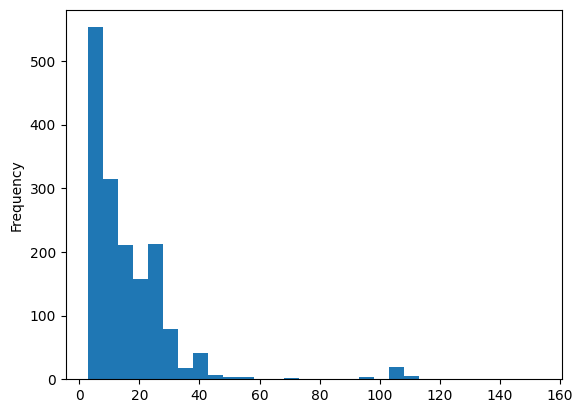

In [317]:
calc_df.natoms.plot.hist(bins=30)

# Save the structures to be calculated

For these structures, we need to compute their MBJ band gaps

Note that we have excluded groups that contains materials only with 0 gap using PBE - this should be lifted later once we are condient of the current search strategy.

In further, the ML predicted (HSE06/experimental) bang gap should be used for screening the groups. 

In [322]:
calc_df = calc_df.loc[calc_df.natoms < 45, :]
print(f'Number of selected structures {len(calc_df)}')

# Structure for MBJ band structure calculation
bg_calc_structures = {index: row.primitive_structure for index, row in calc_df.iterrows()}
dumpfn(bg_calc_structures, 'ternary_mbj_calc_structures.json')

Number of selected structures 1588
